<a href="https://colab.research.google.com/github/Nanthakan670510759/229352-Labs/blob/main/Lab06_SVM_670510759_Nanthakan_rotdi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #6

## Support Vector Machines (SVM)

[SVM module documentation](https://scikit-learn.org/stable/modules/svm.html#svm)

[LinearSVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC)

[SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC  # fast but only linear
from sklearn.svm import SVC  # slower but can do kernels

In [ ]:
# Load the iris data
iris = datasets.load_iris()
X = iris.data[:, 2:]
y = iris.target

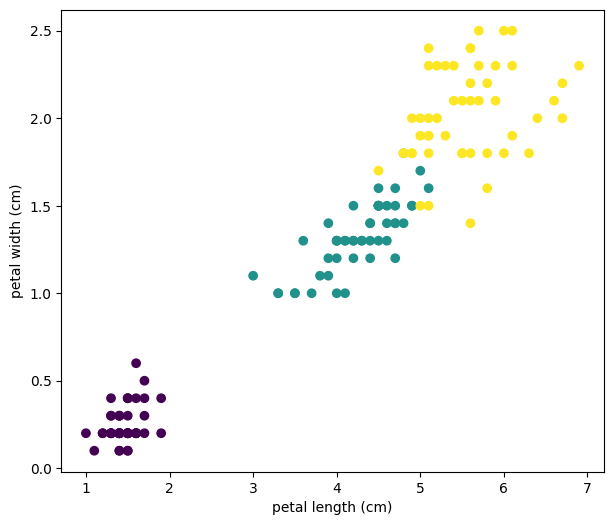

In [ ]:
# Plot the data
plt.figure(figsize=(7,6))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.show()

#### In this problem, you'll use support vector machines to classify the Iris data

#### The following function helps you plot the decision boundary.

In [ ]:
# Plot the decision boundaries
def plot_decision_boundary(clf, X, y):
    h = 0.005  # Boundary lines' resolution
    x_min, x_max = X[:,0].min() - 10*h, X[:,0].max() + 10*h
    y_min, y_max = X[:,1].min() - 10*h, X[:,1].max() + 10*h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, Z, alpha=0.25)  # Background
    plt.contour(xx, yy, Z, colors='k', linewidths=0.2)  # Boundary lines
    plt.scatter(X[:,0], X[:,1], c=y);  # Data points
    plt.xlabel(iris.feature_names[2])
    plt.ylabel(iris.feature_names[3])

#### Exercise 1. Split the data into training set and test set.

In [ ]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

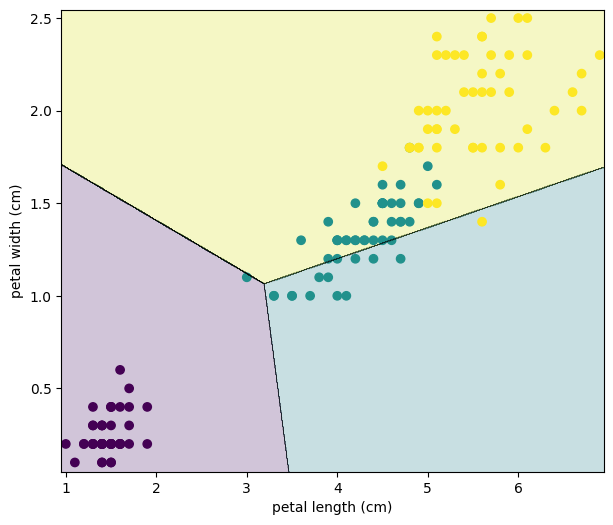

In [ ]:
linesvm=LinearSVC(C=0.1)
linesvm.fit(X_train, y_train)
plot_decision_boundary(linesvm,X,y)

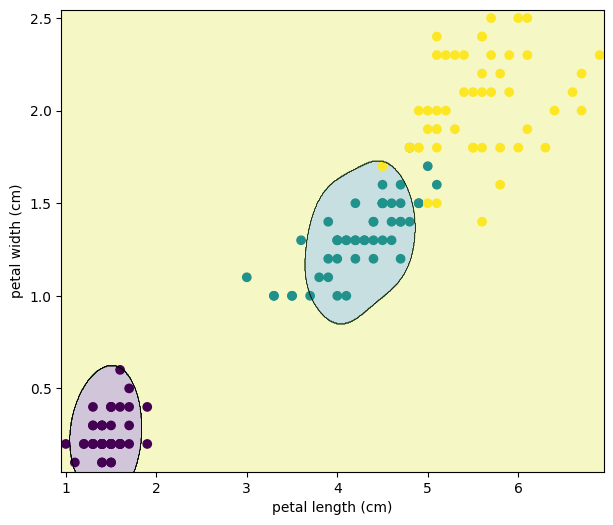

In [ ]:
svm = SVC(C=0.1, kernel='rbf', gamma=10)
svm.fit(X_train, y_train)
plot_decision_boundary(svm, X, y)

#### Exercise 2. Learn a linear SVM classifier using sklearn.svm.LinearSVC. You will need to set `loss='hinge'`.

#### Try different values of the tradeoff parameter: `C = 0.01, 0.1, 1.0, 10.0, 100.0` and use `plot_decision_boundary` to plot the decision boundary.

#### If you encounter `RuntimeError`, consider setting `max_iter=100000`

#### What is the effect of `C` on the decision boundary?

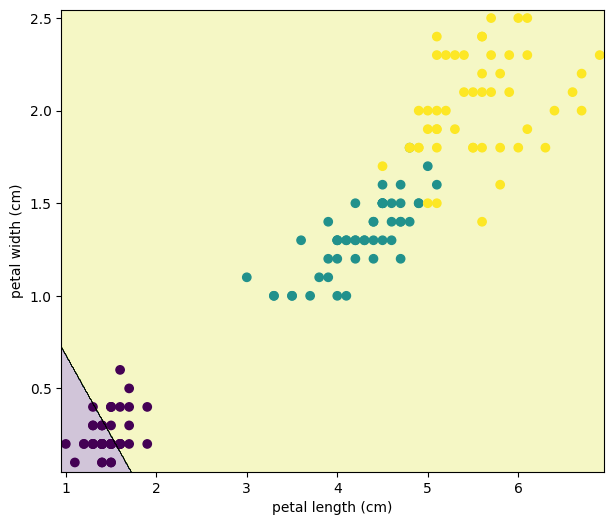

In [ ]:
linesvm=LinearSVC(C=0.01,loss='hinge')
linesvm.fit(X_train, y_train)
plot_decision_boundary(linesvm,X,y)

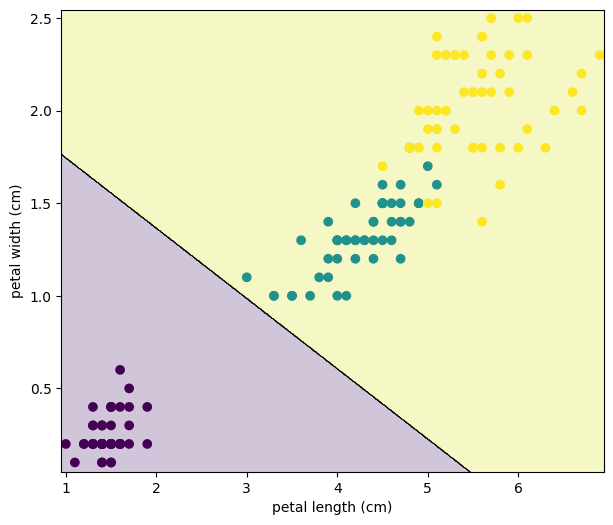

In [ ]:
linesvm=LinearSVC(C=0.1,loss='hinge')
linesvm.fit(X_train, y_train)
plot_decision_boundary(linesvm,X,y)

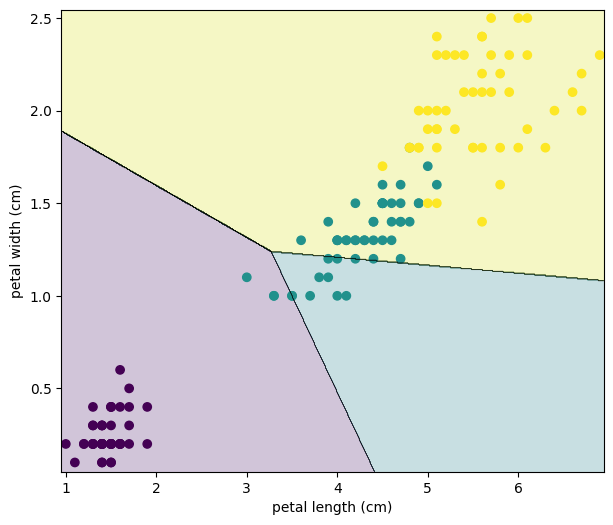

In [ ]:
linesvm=LinearSVC(C=1.0,loss='hinge')
linesvm.fit(X_train, y_train)
plot_decision_boundary(linesvm,X,y)

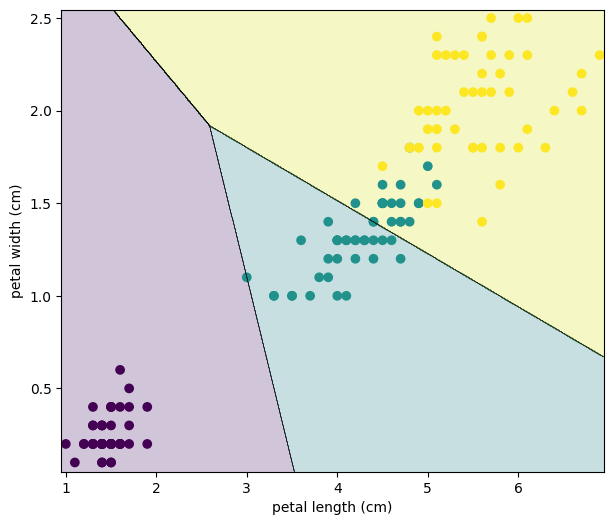

In [ ]:
linesvm=LinearSVC(C=10.0,loss='hinge',max_iter=100000)
linesvm.fit(X_train, y_train)
plot_decision_boundary(linesvm,X,y)

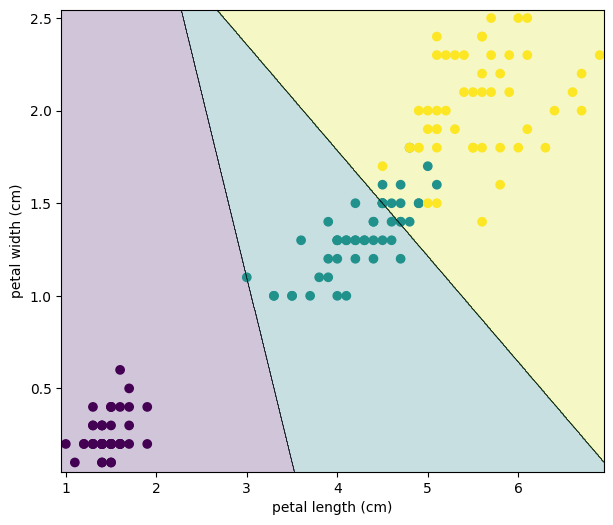

In [ ]:
linesvm=LinearSVC(C=100,loss='hinge',max_iter=100000)
linesvm.fit(X_train, y_train)
plot_decision_boundary(linesvm,X,y)

What is the effect of C on the decision boundary?

Answer ค่า C น้อยหมายถึงการมี Margin ที่กว้าง ซึ่งอาจส่งผลให้มีการละเมิดเข้ามาใน Margin มากขึ้น กรณีค่า C สูงหมายถึงการมี Margin ที่แคบ มีเป้าหมายใน Classify Training Data ให้ถูกมากที่สุด โดยให้ Model มีอิสระในการเลือก Samples เข้ามามากกว่า ในการสร้าง Support Vectors


#### Exercise 3. Pick a value of `C` that you like. Then report the test error.

In [ ]:
linesvm=LinearSVC(C=100,loss='hinge',max_iter=100000)
linesvm.fit(X_train, y_train)
test_accuracy = linesvm.score(x_test, y_test)
test_error = 1-test_accuracy

print(test_error)

0.15555555555555556


#### Exercise 4. Now try kernel SVM with a quadratic kernel. You can do this with sklearn.svm.SVC, setting `kernel='rbf'` and `C = 1.0`.

#### Try different values of the tradeoff parameter: `gamma = 0.01, 0.1, 1.0, 10.0, 100.0` and use `plot_decision_boundary` to plot the decision boundary.

#### If you encounter `RuntimeError`, consider setting `max_iter=100000`

#### What is the effect of `gamma` on the decision boundary?

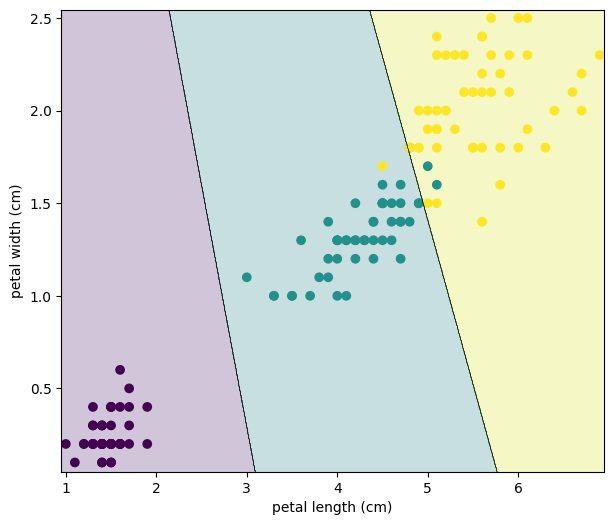

In [ ]:
svm = SVC(C=1.0, kernel='rbf',gamma=0.01)
svm.fit(X_train, y_train)
plot_decision_boundary(svm, X, y)

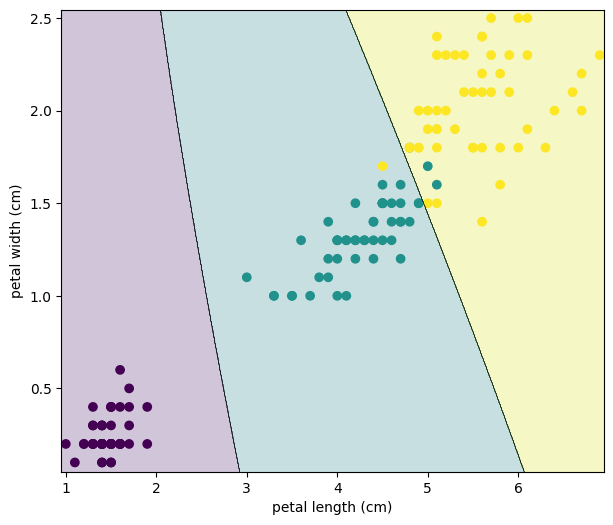

In [ ]:
svm = SVC(C=1.0, kernel='rbf',gamma=0.1)
svm.fit(X_train, y_train)
plot_decision_boundary(svm, X, y)

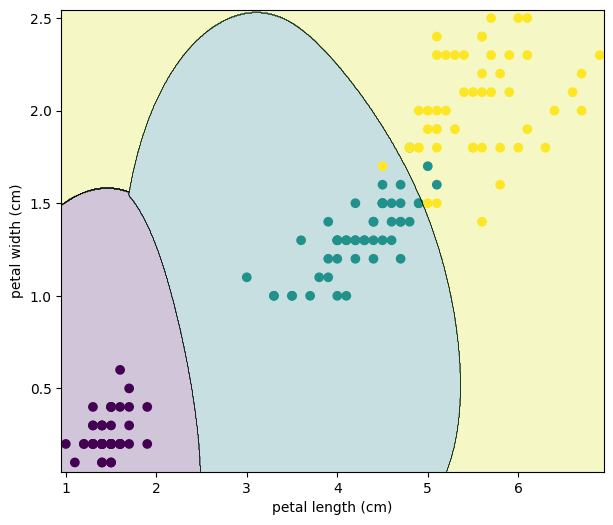

In [ ]:
svm = SVC(C=1.0, kernel='rbf',gamma=1.0)
svm.fit(X_train, y_train)
plot_decision_boundary(svm, X, y)

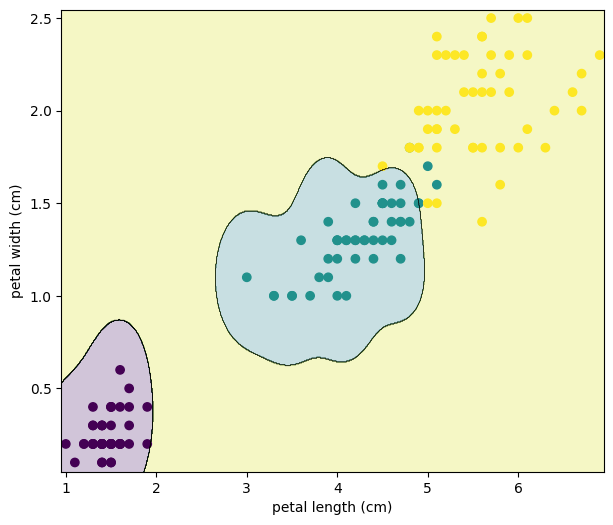

In [ ]:
svm = SVC(C=1.0, kernel='rbf',gamma=10)
svm.fit(X_train, y_train)
plot_decision_boundary(svm, X, y)

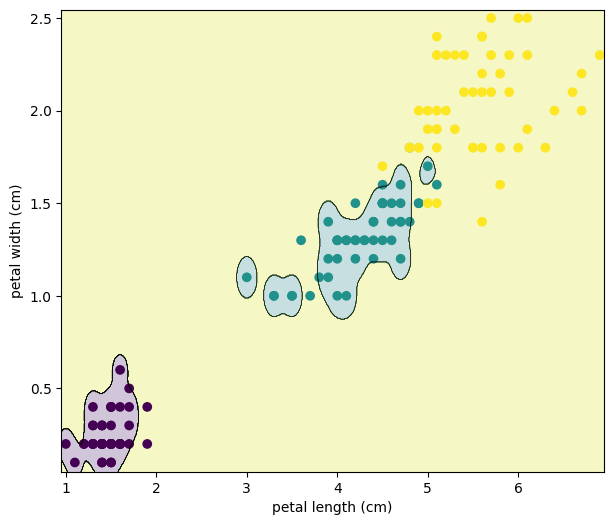

In [ ]:
svm = SVC(C=1.0, kernel='rbf',gamma=100)
svm.fit(X_train, y_train)
plot_decision_boundary(svm, X, y)

What is the effect of gamma on the decision boundary?

Answer gamma กำหนดความแคบของส่วนโค้งซึ่งมีรูปร่างตามการกระจายแบบ Gaussian กรณีค่า gamma น้อยหมายถึง decision boundary เรียบง่าย กรณีค่า gamma สูงหมายถึง decision boundary งอไปตามจุดข้อมูลและมีรูปร่างซับซ้อน

#### Exercise 5. Pick a value of `gamma` that you like. Then report the test error and the number of support vectors.

In [ ]:
svm = SVC(C=1.0, kernel='rbf',gamma=100)
svm.fit(X_train, y_train)
test_accuracy = svm.score(x_test, y_test)
test_error = 1-test_accuracy

num_sv = svm.n_support_

print(test_error)
print(num_sv)

0.19999999999999996
[19 26 33]


#### Exercise 6. Between Linear SVM and Kernel SVM, which model would you prefer to use for classification of Iris data?
1. Explain using test accuracy
2. Explaing using decision boundary plot

In [ ]:
linesvm=LinearSVC(C=100,loss='hinge',max_iter=100000)
linesvm.fit(X_train, y_train)
test_accuracy = linesvm.score(x_test, y_test)
print(test_accuracy)

0.8444444444444444


In [ ]:
svm = SVC(C=1.0, kernel='rbf',gamma=100,max_iter=100000)
svm.fit(X_train, y_train)
test_accuracy = svm.score(x_test, y_test)
print(test_accuracy)

0.8


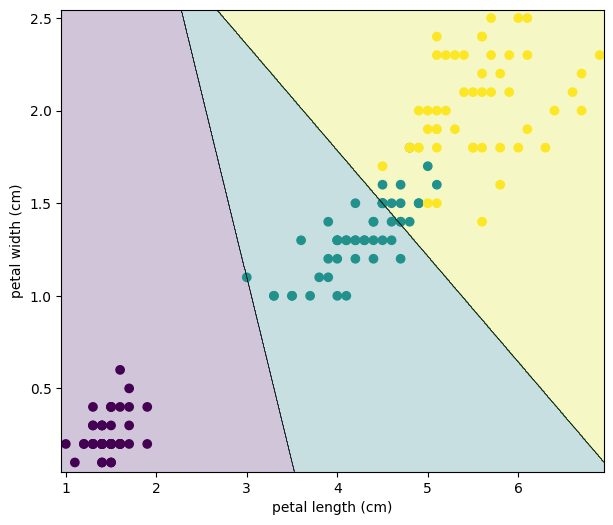

In [ ]:
linesvm=LinearSVC(C=100,loss='hinge',max_iter=100000)
linesvm.fit(X_train, y_train)
plot_decision_boundary(linesvm,X,y)

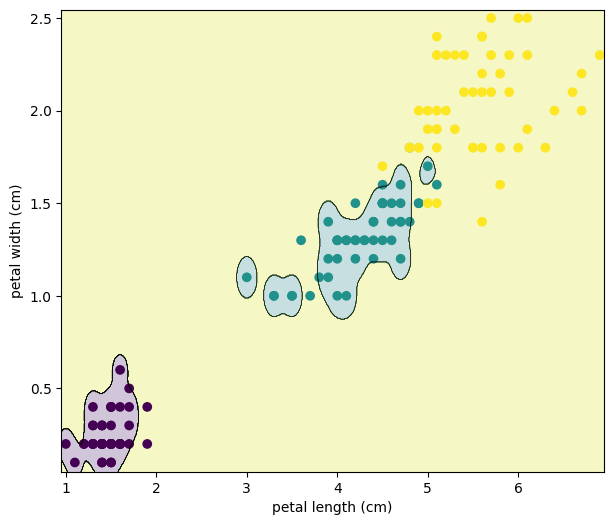

In [ ]:
svm = SVC(C=1.0, kernel='rbf',gamma=100,max_iter=100000)
svm.fit(X_train, y_train)
plot_decision_boundary(svm, X, y)

1.เลือกโมเดล Linear SVM สำหรับข้อมูล เนื่องจาก Linear SVM มีค่า test accuracy สูงกว่า Kernel SVM

2.โมเดล Linear SVM เรียบง่ายและแยกคลาสได้ชัดเจนกว่า  Kernel SVM